# Xenium Breast 5K Medium Crop: cellAdmix Membrane Scoring

## Overview

This is a medium-crop version of the breast 5K membrane-scoring
notebook, meant for fast iteration on content, layout, and diagnostics
before rerunning the full dataset. The crop is large enough to contain
both immune-rich and tumor-epithelial domains, but much smaller than the
full 82M-molecule dataset.

## Inputs and Crop

The annotation notebook writes `annotations/annotation.csv.gz` and
`annotations/domain_annotation.csv.gz`. We keep the same annotations
here but construct a cropped cellAdmix dataset using `analysis_bbox`.

For this 5K panel we use stricter cell-complexity thresholds in the
annotation and cell-state UMAP diagnostics: `min_molecules = 30` and
`min_genes = 15`. The lower defaults produced many small low-complexity
UMAP islands in this dataset.

In [ ]:
bundle_dir <- "data"
output_dir <- "out_medium_crop"
annotation_file <- file.path("annotations", "annotation.csv.gz")
domain_file <- file.path("annotations", "domain_annotation.csv.gz")
analysis_bbox <- c(5000, 7000, 4500, 6500)

annotation <- read.csv(annotation_file, stringsAsFactors = FALSE)
domain_annotation <- read.csv(domain_file, stringsAsFactors = FALSE)

in_crop <- annotation$cell_id %in% domain_annotation$cell_id[
  domain_annotation$x >= analysis_bbox[[1]] &
    domain_annotation$x <= analysis_bbox[[2]] &
    domain_annotation$y >= analysis_bbox[[3]] &
    domain_annotation$y <= analysis_bbox[[4]]
]
table(annotation$merged_annotation[in_crop])


Ambiguous / low-quality              B / plasma             Endothelial 
                   3133                    1498                     810 
             Epithelial        Fibroblast / CAF                 Myeloid 
                  14839                     648                    3499 
                 T / NK 
                   7085 


     immune_rich tumor_epithelial 
           20106            11406 

Cells labeled `Ambiguous / low-quality` are retained in side plots but
excluded from the active fit/scoring annotation.

In [ ]:
cell_annotation <- setNames(annotation$merged_annotation, annotation$cell_id)
cell_annotation <- cell_annotation[cell_annotation != "Ambiguous / low-quality"]

ds <- cellAdmix(bundle_dir, output_dir = output_dir, annotation = cell_annotation,
  num_threads = 10, analysis_bbox = analysis_bbox)

ds

cellAdmix dataset
  format: xenium 
  output cache: configured
  threads: 10 
  molecules: transcripts.parquet 
  cells: cells.parquet 
  annotation:manual (422675 cells, 6 labels)

## Fit Factors

In [ ]:
fit <- ds$fit(verbose = TRUE)

[INFO 13:53:31 +0.025s] Reused compatible Xenium input store (0.000s)
[INFO 13:53:31 +0.025s] Built Xenium input store: 8189365 molecules, 34541 cells (0.025s)
[INFO 13:53:31 +0.000s] Starting store-backed fit
[INFO 13:53:31 +0.825s] Resolved store training strata for 34541 cells (0.323s)

cellAdmix fit
  run: fit_manual_rank8_invsqrt_kl 
  annotation: manual 
  rank: 8 
  NMF: invsqrt_kl 
  molecule scoring: gene_loadings 
  cells: 34541 
  transcripts: 8189365 

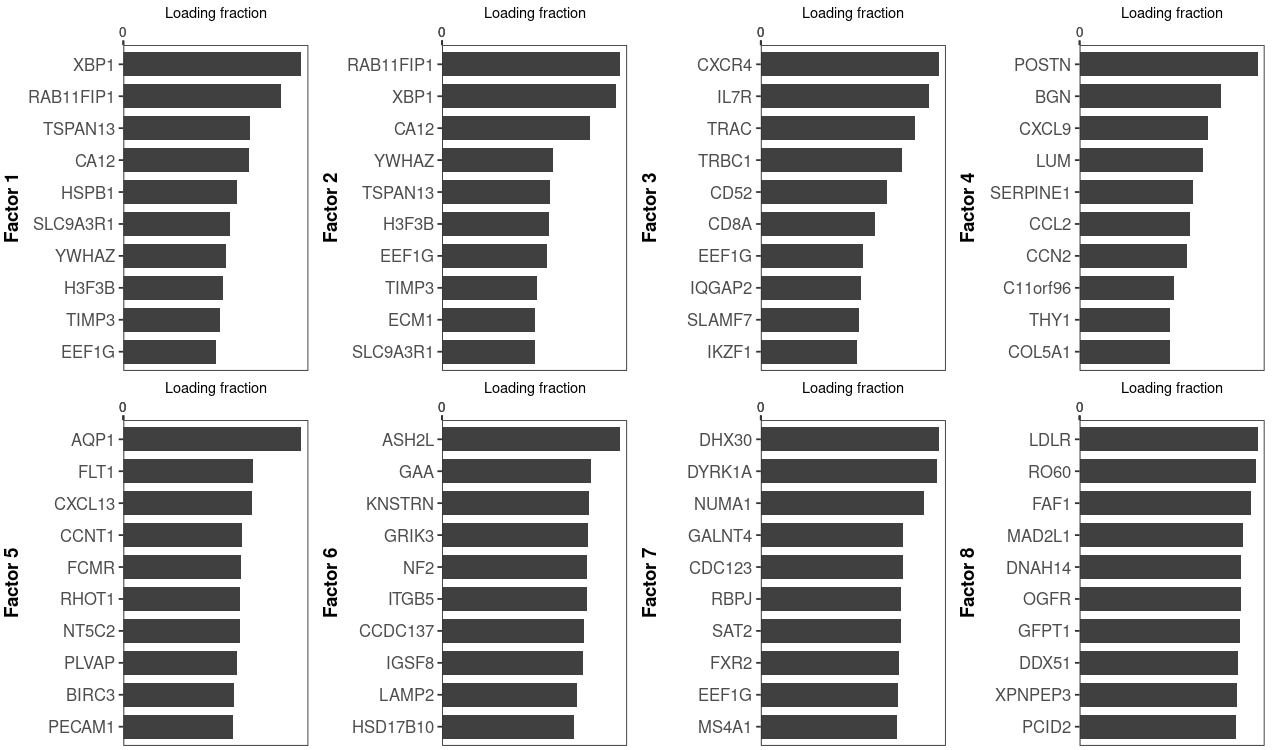

In [ ]:
fit$plot_loadings()

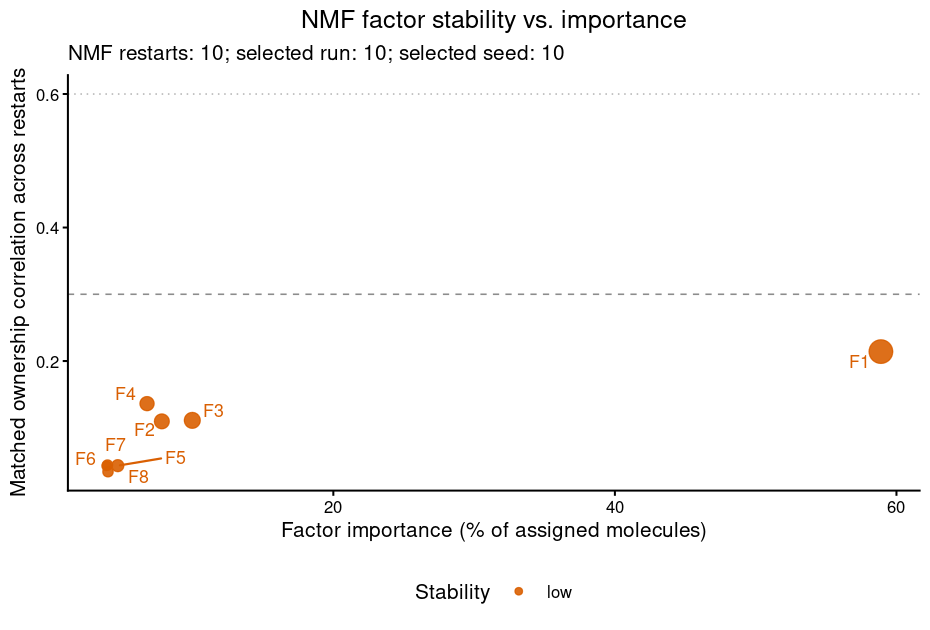

In [ ]:
fit$plot_stability()

## Tissue Context

In [ ]:
cell_factors <- fit$cell_factors()
cell_spatial <- merge(cell_factors,
  annotation[, c("cell_id", "merged_annotation", "cluster_label")],
  by = "cell_id", all.x = FALSE, sort = FALSE)
cell_spatial <- merge(cell_spatial,
  domain_annotation[, c("cell_id", "domain_label")],
  by = "cell_id", all.x = FALSE, sort = FALSE)
cell_spatial$domain_label <- factor(cell_spatial$domain_label,
  levels = c("immune_rich", "tumor_epithelial"))

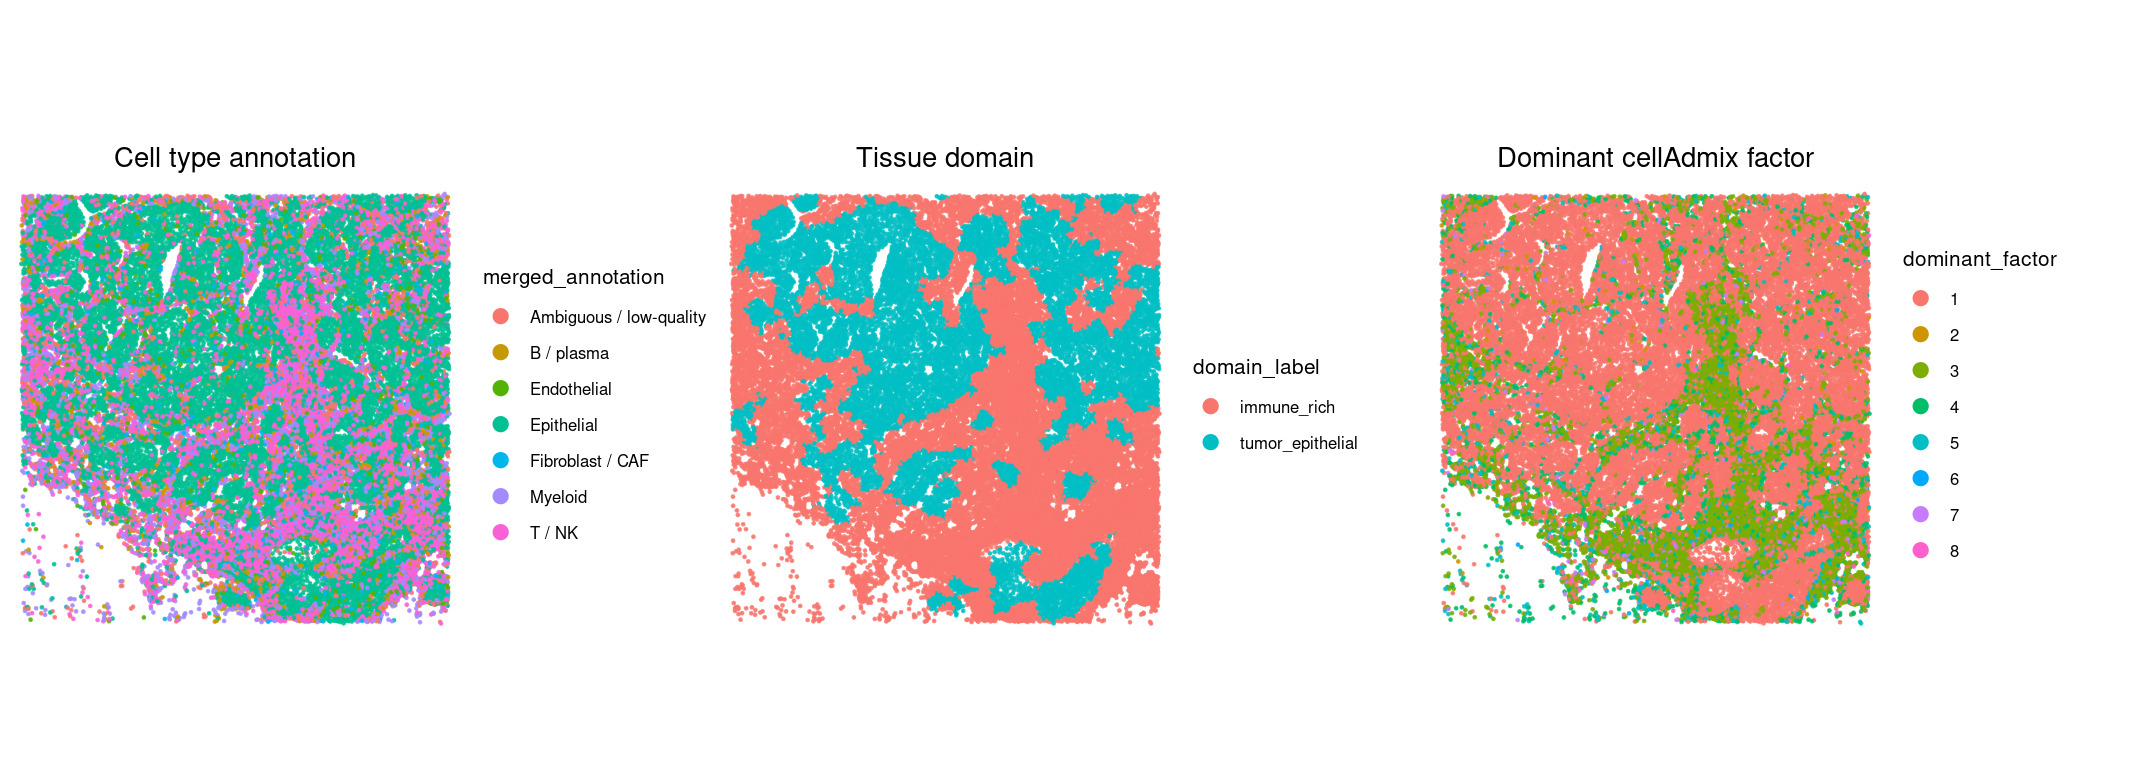

In [ ]:
cowplot::plot_grid(plotlist = list(
  celladmix_plot_spatial(cell_spatial, color_by = "merged_annotation",
    point_size = 0.18) +
    ggtitle("Cell type annotation"),
  celladmix_plot_spatial(cell_spatial, color_by = "domain_label",
    point_size = 0.18) +
    ggtitle("Tissue domain"),
  celladmix_plot_spatial(cell_spatial, color_by = "dominant_factor",
    point_size = 0.18) +
    ggtitle("Dominant cellAdmix factor")
), ncol = 3, align = "hv", axis = "tblr")

## Diagnostic Setup

In [ ]:
diagnostic_cell_types <- c("Fibroblast / CAF", "Endothelial")

epithelial_tumor_markers <- c("EPCAM", "KRT8", "KRT18", "KRT19", "MUC1",
  "GATA3", "CA12", "XBP1", "ERBB2")
lymphoid_myeloid_markers <- c("TRAC", "TRBC1", "CD3D", "CD3E", "CD8A",
  "IL7R", "MS4A1", "CD79A", "AIF1", "C1QC", "MS4A6A", "ITGAX")
source_marker_sets <- list(
  "epithelial/tumor source" = epithelial_tumor_markers,
  "immune source" = lymphoid_myeloid_markers
)

In [ ]:
original_counts <- fit$counts()
diagnostic_de_original <- celladmix_de_by_group(original_counts, cell_spatial,
  subset_by = "merged_annotation", subsets = diagnostic_cell_types,
  group_by = "domain_label", contrast = c("tumor_epithelial", "immune_rich"))

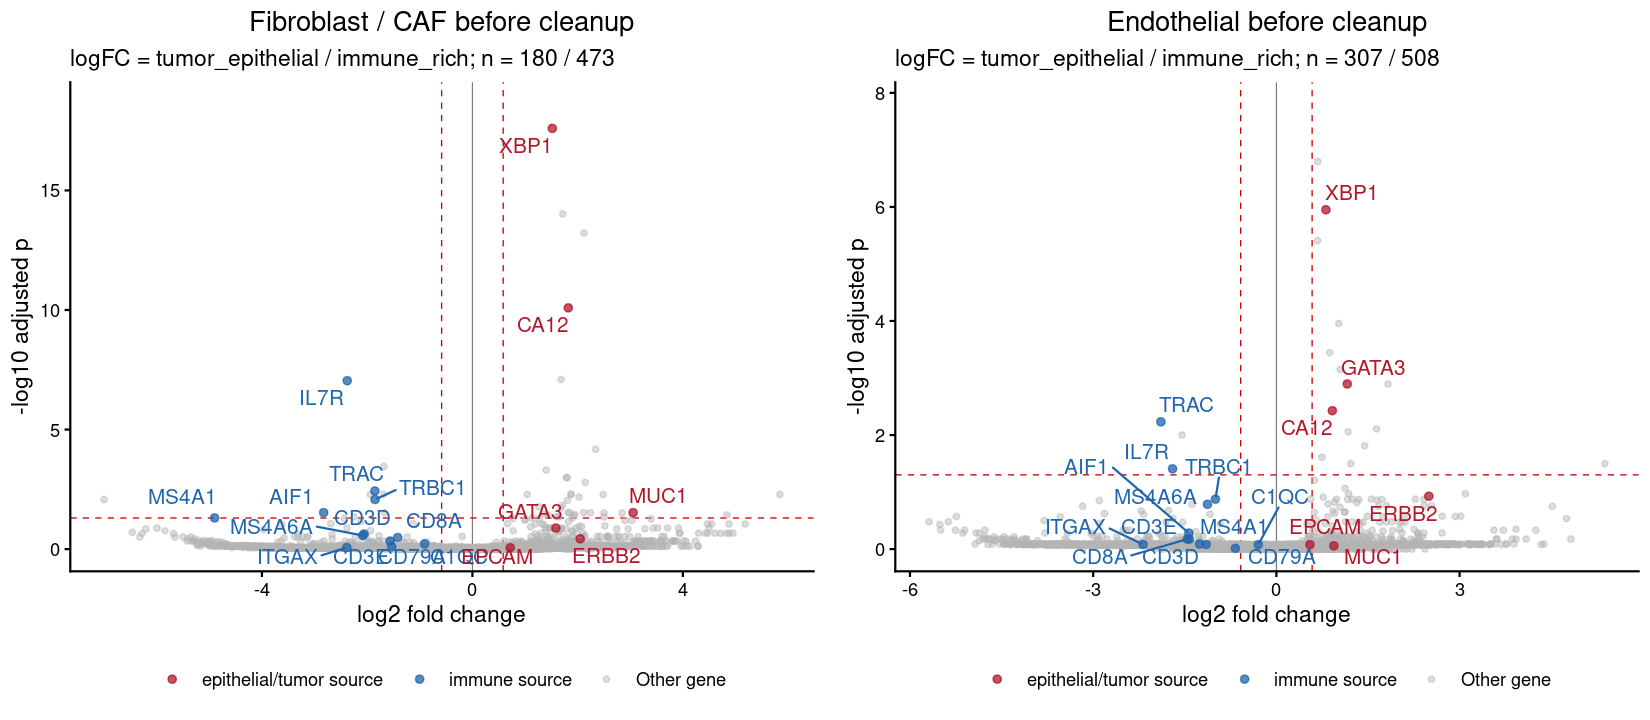

In [ ]:
baseline_volcano_plots <- lapply(diagnostic_cell_types, function(target_type) {
  de <- diagnostic_de_original[[target_type]]
  celladmix_plot_volcano(de, markers = source_marker_sets,
    title = paste(target_type, "before cleanup"),
    subtitle = sprintf("logFC = tumor_epithelial / immune_rich; n = %d / %d",
      unique(de$n_group_a), unique(de$n_group_b)))
})
cowplot::plot_grid(plotlist = baseline_volcano_plots,
  ncol = length(baseline_volcano_plots), align = "hv", axis = "tblr")

## Membrane Scoring

This crop is small enough that a permissive rule threshold can produce
broad cleanup calls. We use a stricter `p_thresh = 0.01` here to keep
the exploratory crop diagnostics interpretable before moving back to
full-dataset settings.

In [ ]:
p_thresh <- 0.01
score_pairs_width <- 9.6
score_pairs_height <- max(6, ceiling(fit$rank / 2) * 4.9)

In [ ]:
membrane_score <- fit$score_membrane()
membrane_annotation <- membrane_score$annotation(p_thresh = p_thresh)
membrane_rules <- membrane_score$rules(p_thresh = p_thresh)

head(membrane_rules[, c("factor", "source_cell_type", "target_cell_type", "p_value")])

  factor source_cell_type target_cell_type      p_value
1      1       Epithelial       B / plasma 0.0026319646
2      1       Epithelial          Myeloid 0.0008728155
3      1       Epithelial           T / NK 0.0083117305
4      3           T / NK       B / plasma 0.0061225718
5      3           T / NK      Endothelial 0.0053717949
6      3           T / NK       Epithelial 0.0009224255

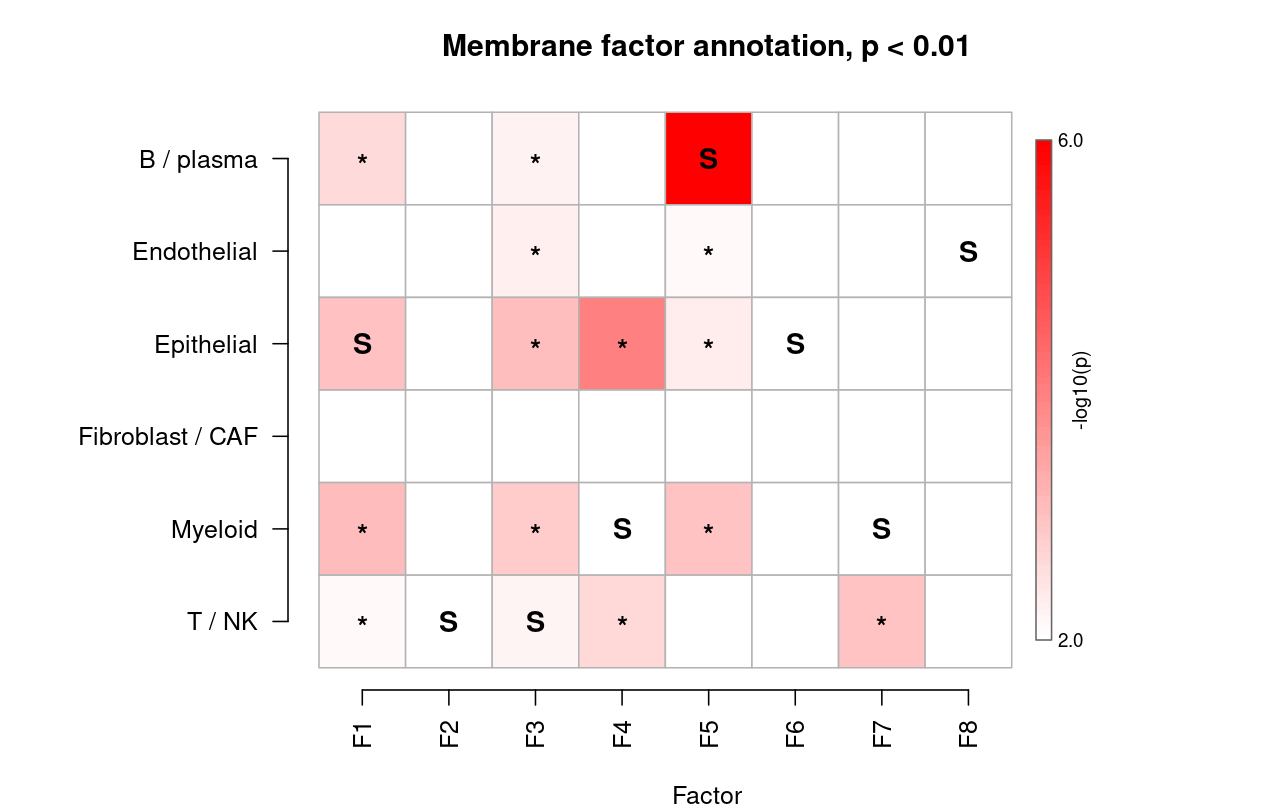

In [ ]:
membrane_score$plot_heatmap(p_thresh = p_thresh)

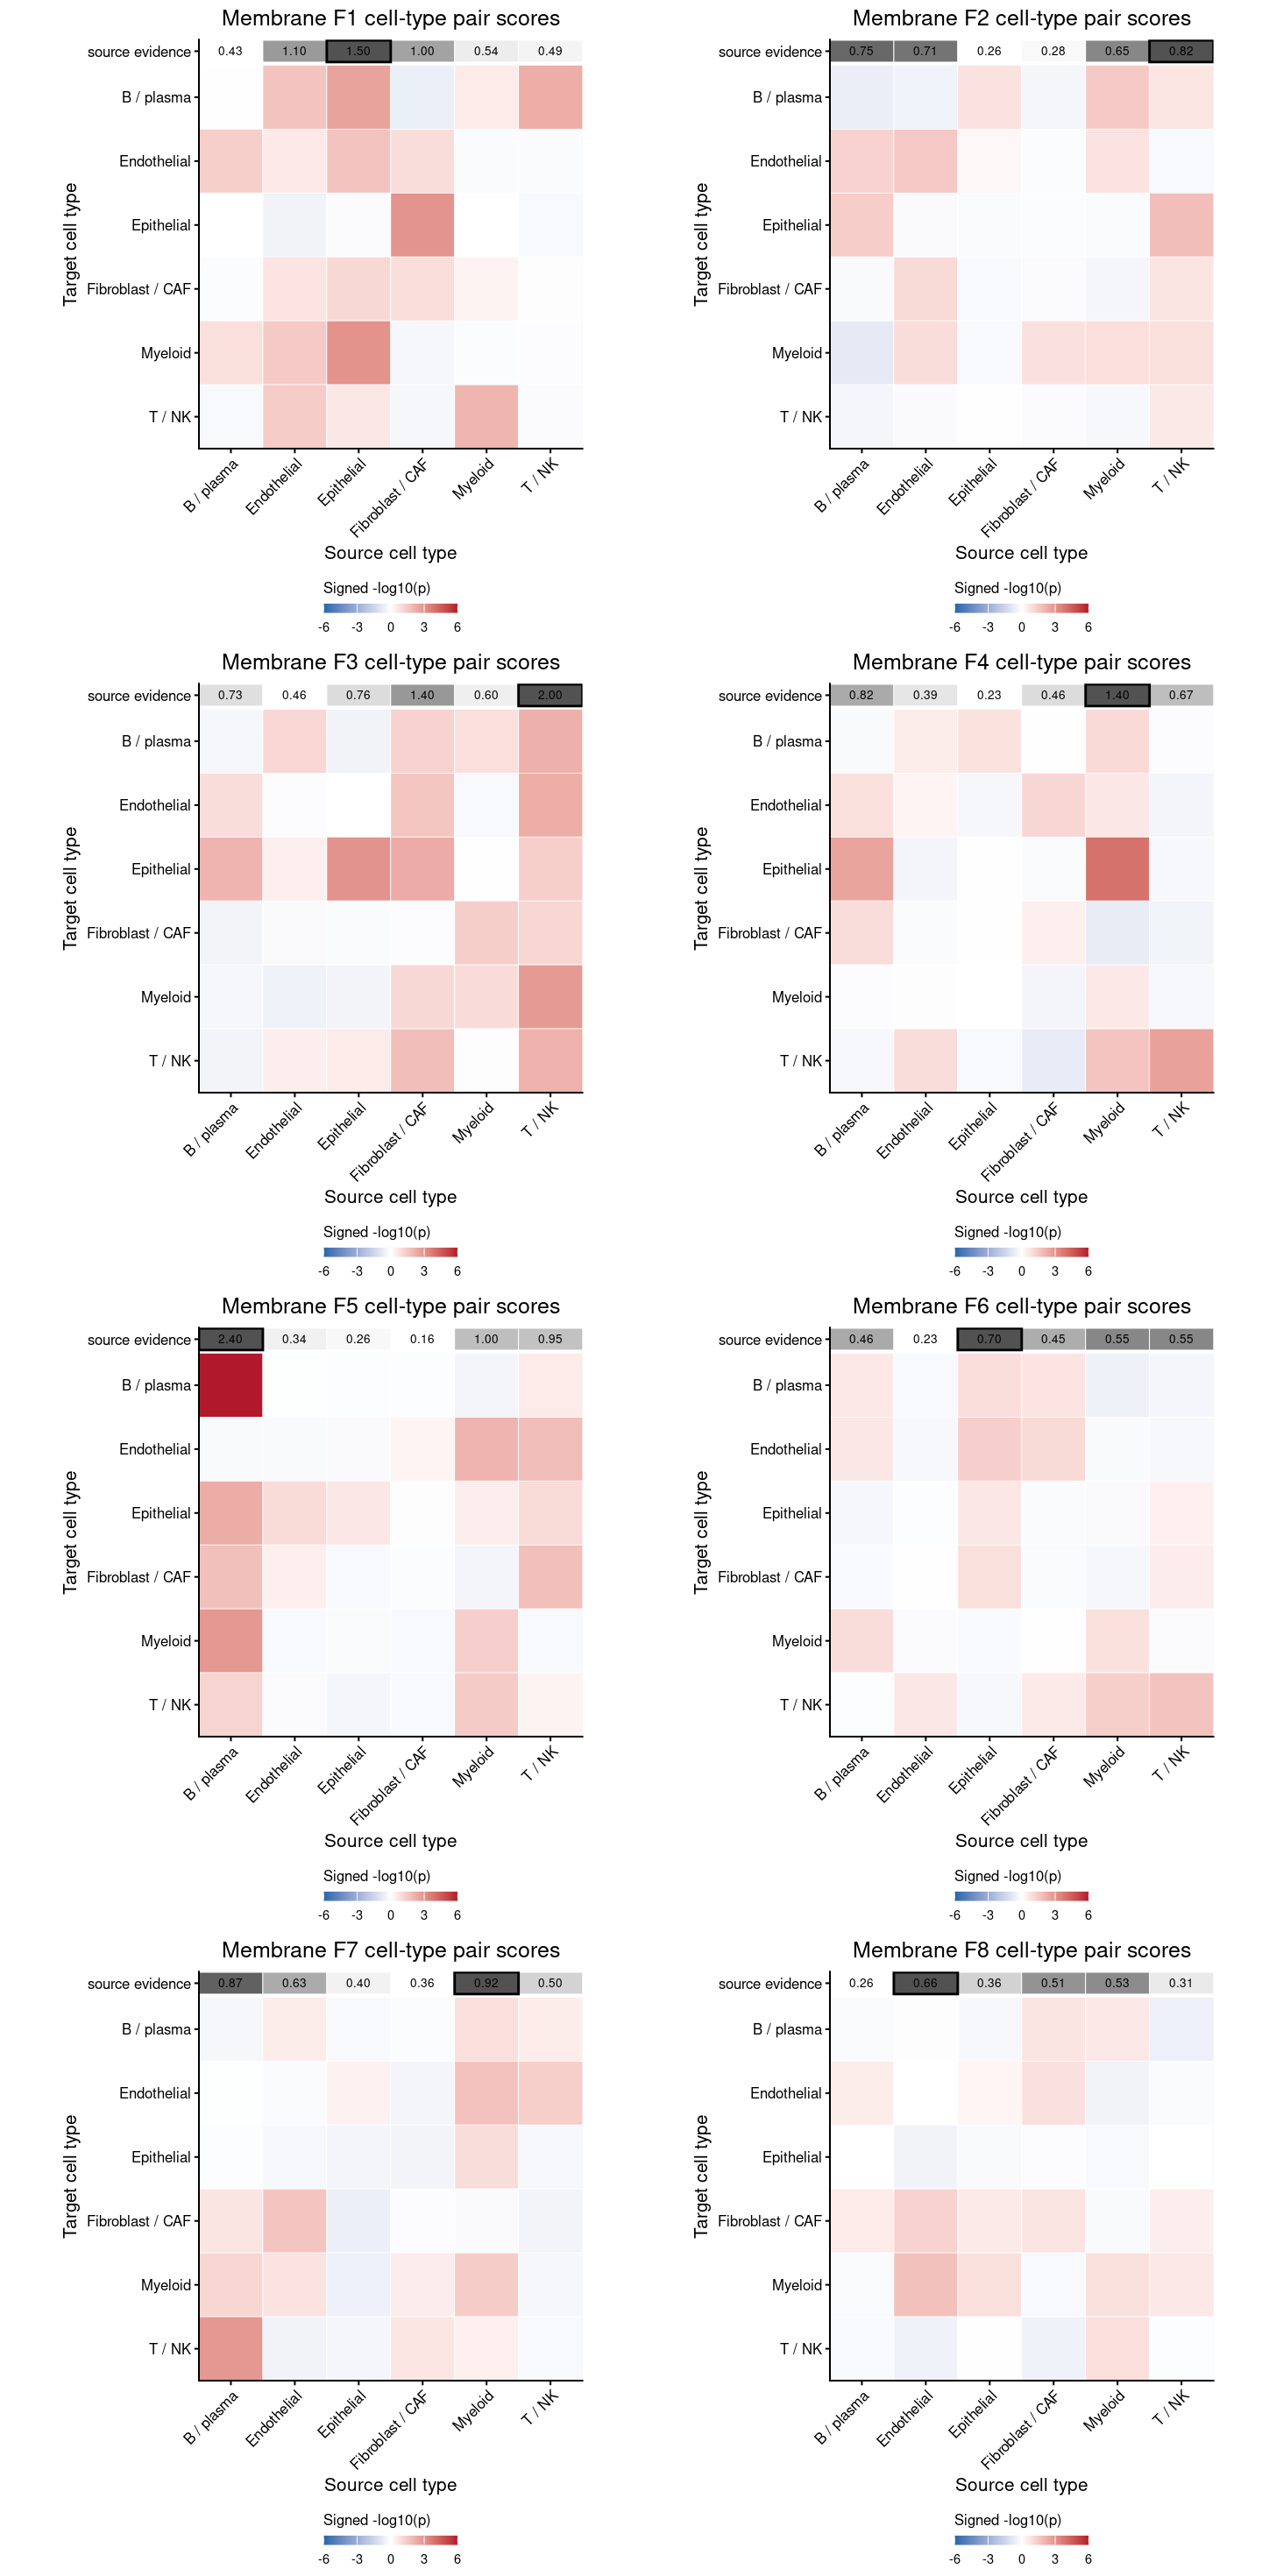

In [ ]:
membrane_score$plot_pairs()

## Example Cells

These examples show the molecule-level interpretation for selected
diagnostic cells before cleanup. The examples are chosen from cells with
strong rule-supported membrane-score evidence. Molecule colors show the
native factor set in blue, the top putative admixture factor in red, and
other non-native factors in orange. Source-marker molecules are drawn
slightly larger.

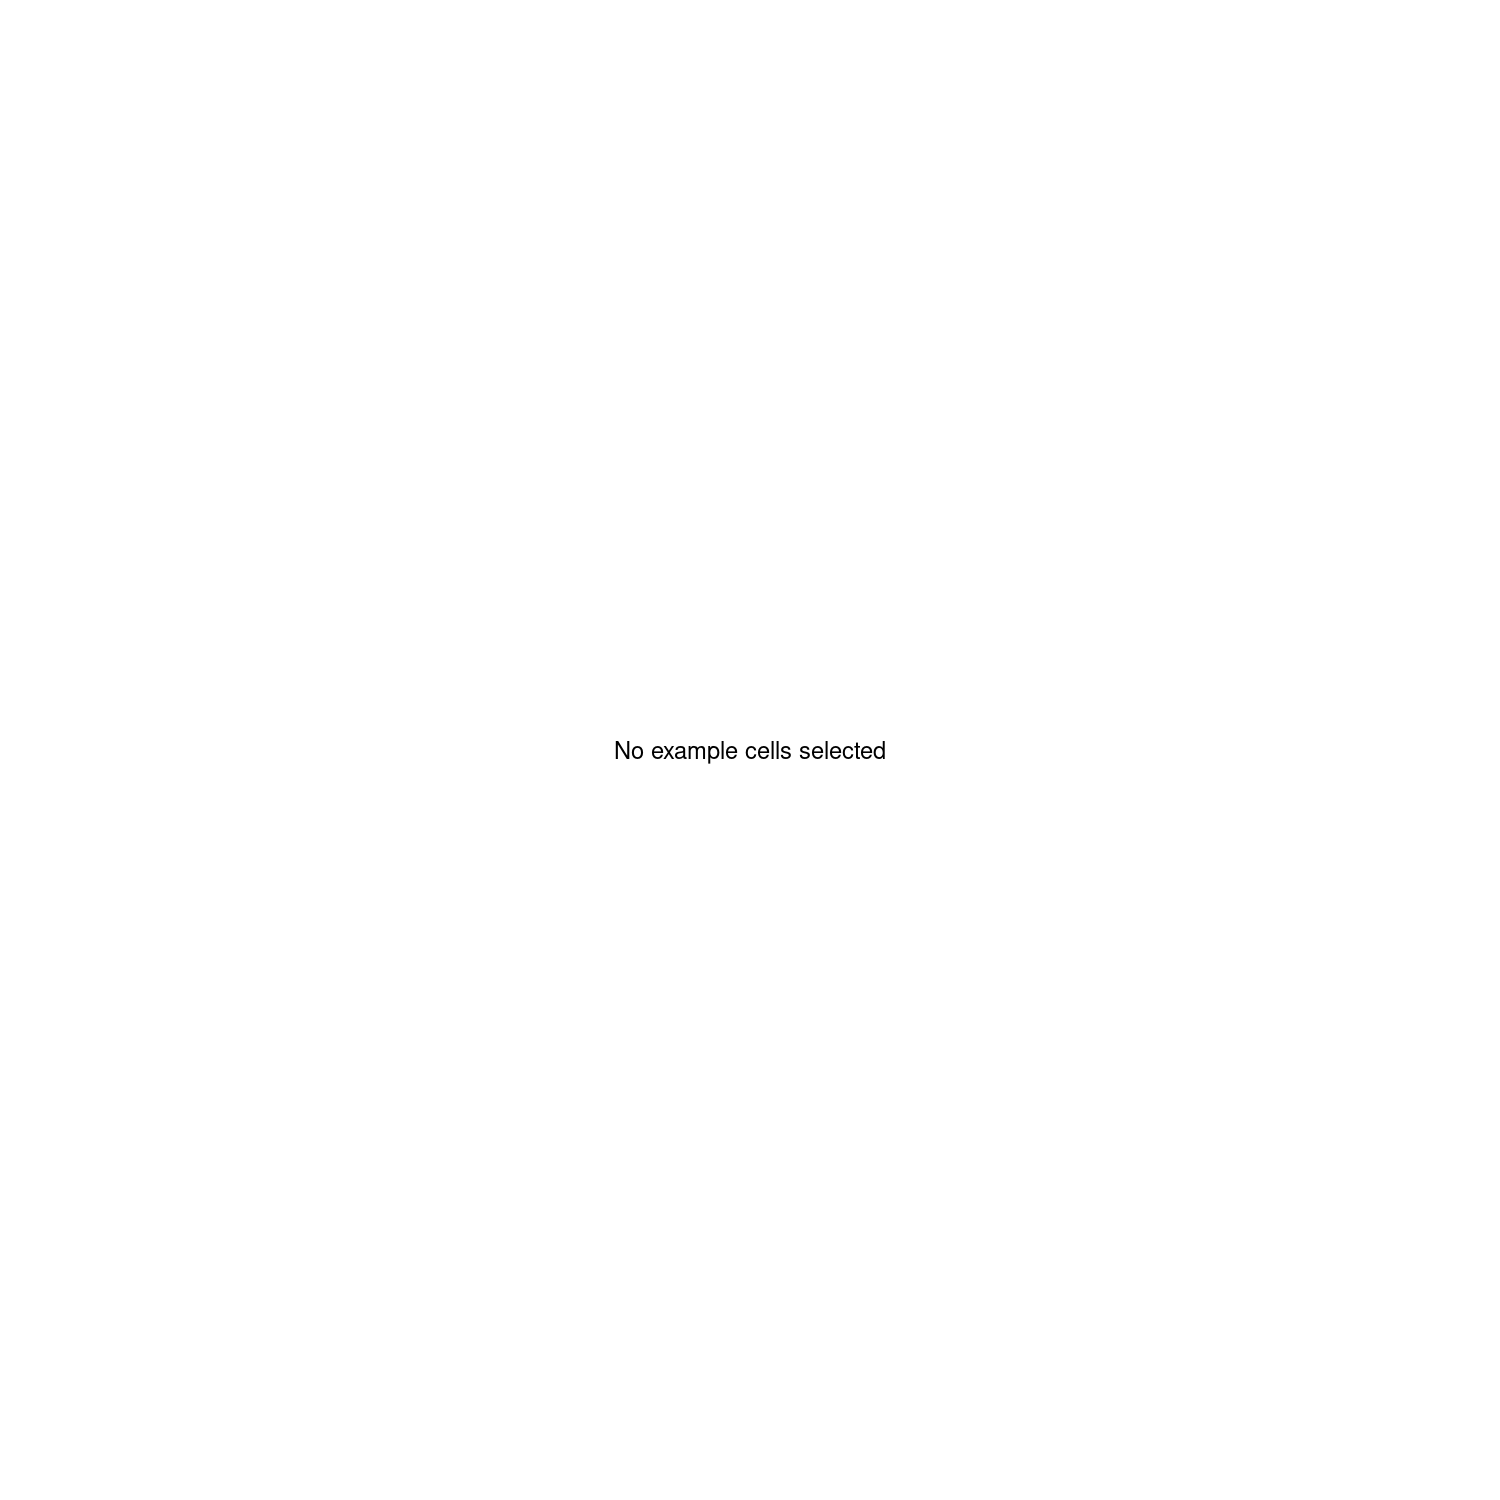

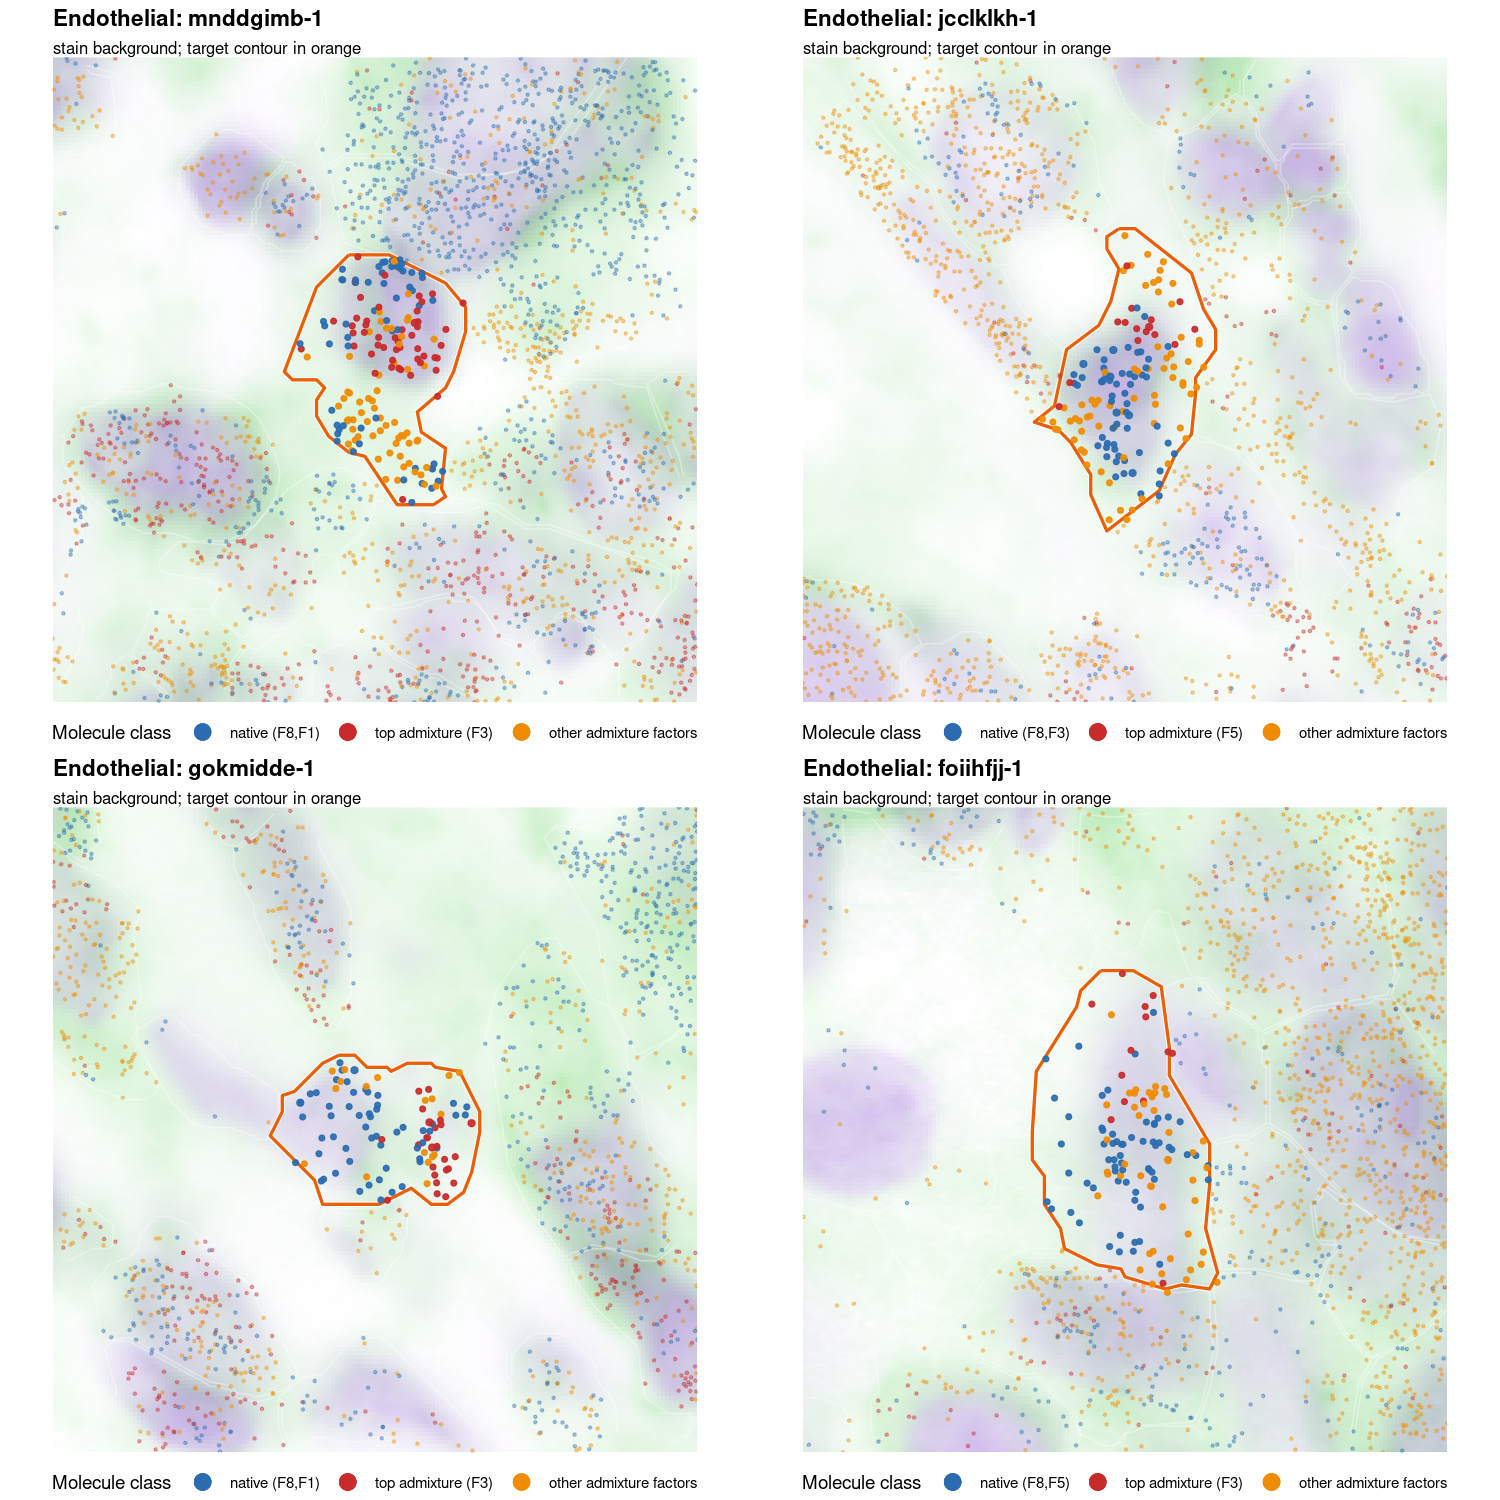

In [ ]:
dapi_stain <- fit$stain("dapi")
membrane_stain <- fit$stain("membrane")
cell_boundaries <- fit$cell_boundaries()
example_cells <- membrane_score$examples(rules = membrane_rules,
  score_annotation = membrane_annotation, cell_data = cell_spatial,
  targets = diagnostic_cell_types, n_per_target = 4)

for (cell_type in diagnostic_cell_types) {
  type_examples <- example_cells[example_cells$target_cell_type == cell_type, , drop = FALSE]
  print(membrane_score$plot_examples(type_examples,
    score_annotation = membrane_annotation, cell_data = cell_spatial,
    boundaries = cell_boundaries,
    stains = list(dapi = dapi_stain, membrane = membrane_stain),
    markers = unique(unlist(source_marker_sets)), ncol = 2))
}

## Cleanup Diagnostics

In [ ]:
membrane_correction <- membrane_score$correct(rules = membrane_rules,
  name = "membrane_clean_p001")
membrane_counts <- membrane_correction$counts()

membrane_correction$summary()

         cell_type n_cells n_modified_cells fraction_cells_modified
1              all   34541            27820               0.8054196
2       B / plasma    1522             1515               0.9954008
3      Endothelial     815              769               0.9435583
4       Epithelial   14953            14919               0.9977262
5 Fibroblast / CAF     653                0               0.0000000
6          Myeloid    3534             3522               0.9966044
7           T / NK    7130             7095               0.9950912
8          unknown    5934                0               0.0000000
  molecules_before molecules_after molecules_removed fraction_molecules_removed
1          8189365         6922141           1267224                 0.15474020
2           306036          199766            106270                 0.34724673
3            64415           50874             13541                 0.21021501
4          5963412         5369997            593415                

In [ ]:
membrane_de <- celladmix_de_by_group(membrane_counts, cell_spatial,
  subset_by = "merged_annotation", subsets = diagnostic_cell_types,
  group_by = "domain_label", contrast = c("tumor_epithelial", "immune_rich"))

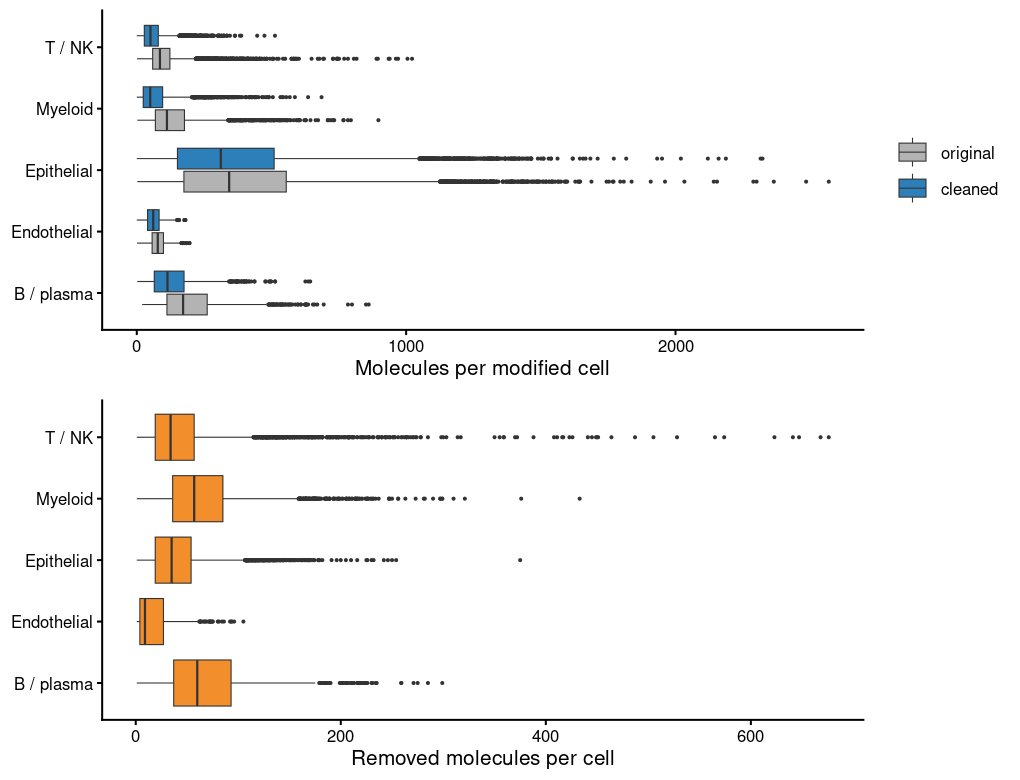

In [ ]:
membrane_correction$plot_removed_molecules()

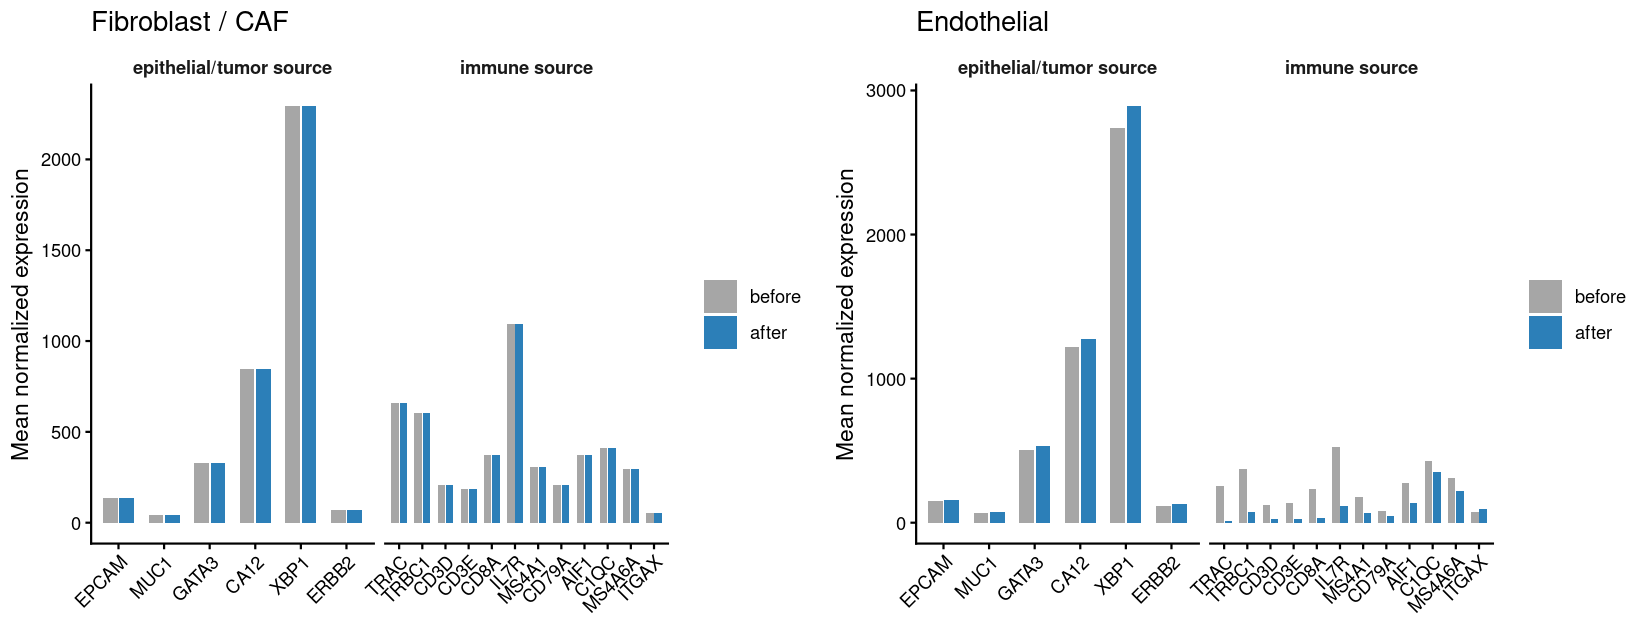

In [ ]:
plots <- lapply(diagnostic_cell_types, function(cell_type) {
  cells <- cell_spatial$cell_id[cell_spatial$merged_annotation == cell_type]
  celladmix_plot_marker_expression(original_counts, membrane_counts,
    cells = cells, markers = source_marker_sets) +
    ggtitle(cell_type)
})
cowplot::plot_grid(plotlist = plots, ncol = length(plots), align = "hv", axis = "tblr")

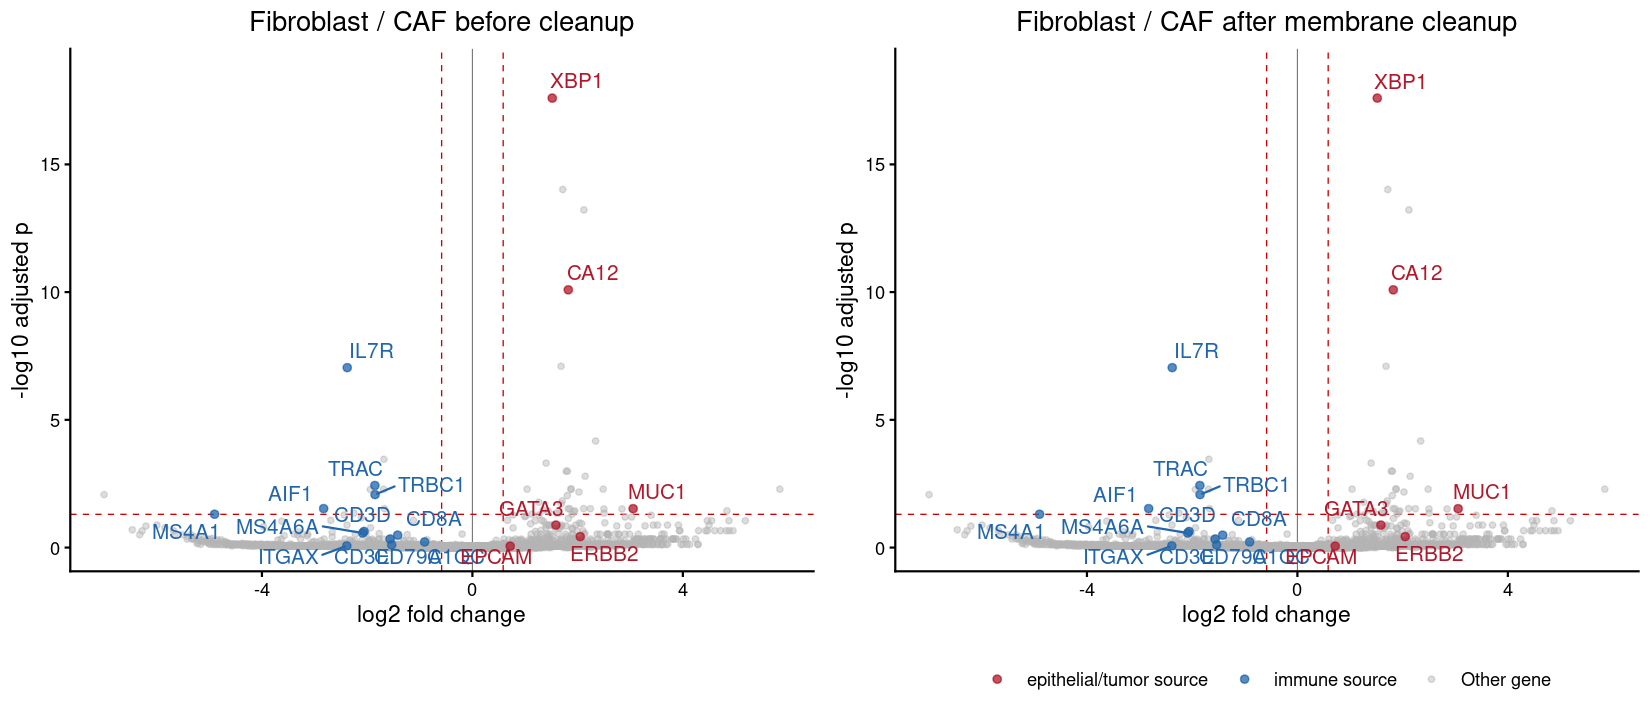

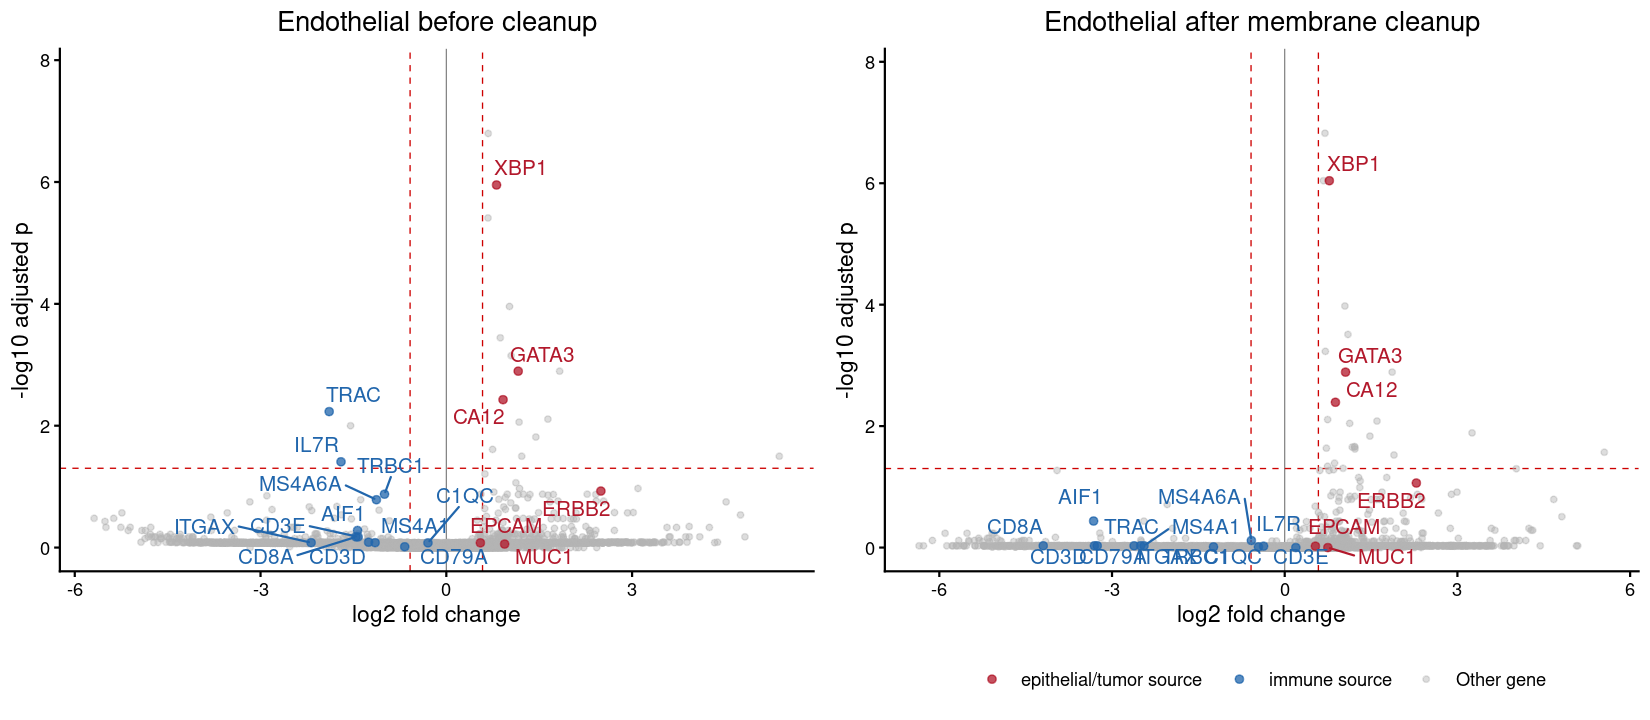

In [ ]:
for (target_type in diagnostic_cell_types) {
  p_before <- celladmix_plot_volcano(diagnostic_de_original[[target_type]],
    markers = source_marker_sets, title = paste(target_type, "before cleanup")) +
    theme(legend.position = "none")
  p_after <- celladmix_plot_volcano(membrane_de[[target_type]],
    markers = source_marker_sets, title = paste(target_type, "after membrane cleanup"))
  print(cowplot::plot_grid(plotlist = list(p_before, p_after),
    ncol = 2, align = "hv", axis = "tblr"))
}

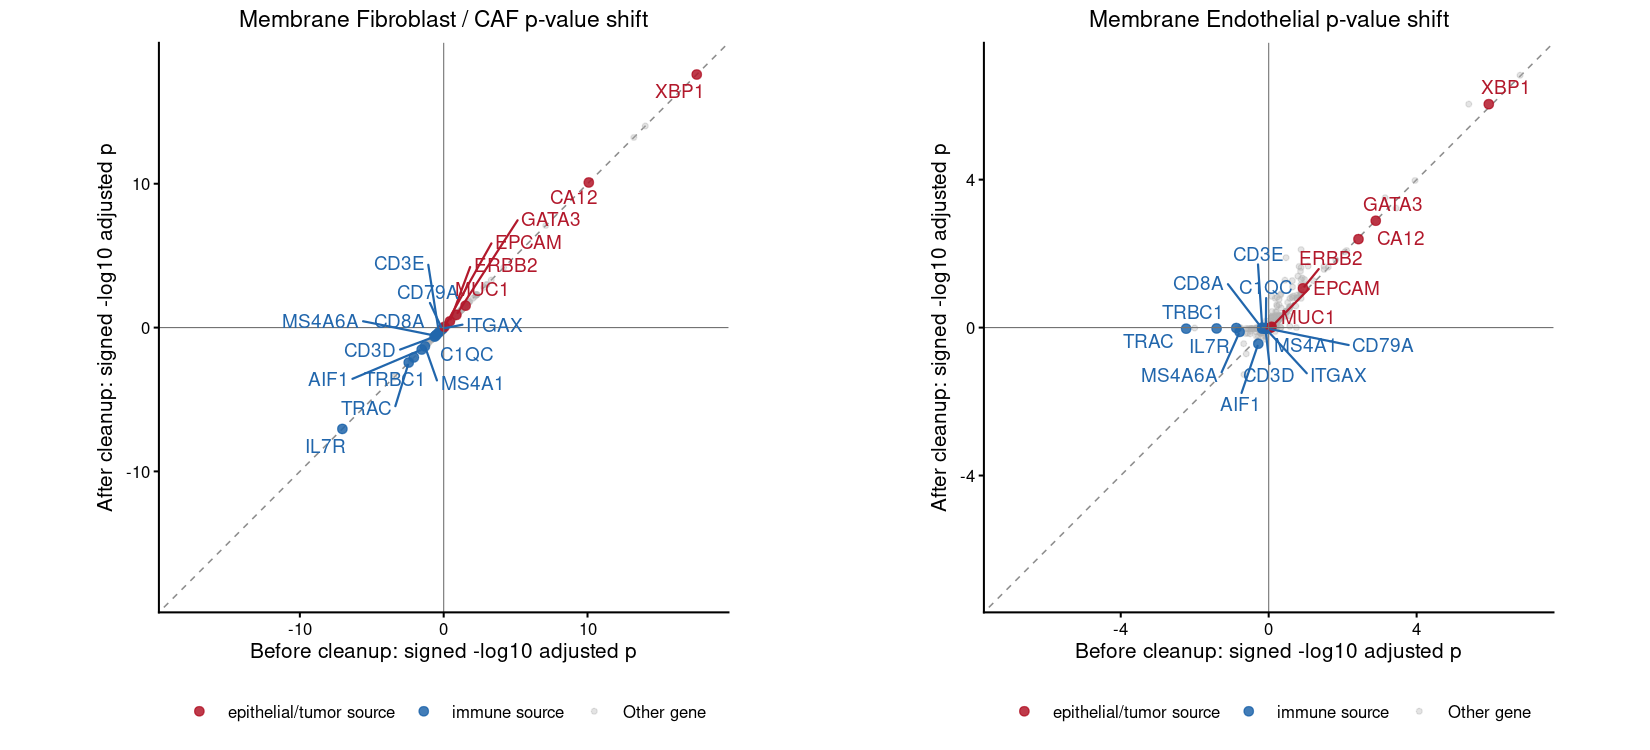

In [ ]:
plots <- lapply(diagnostic_cell_types, function(target_type) {
  celladmix_plot_de_shift(diagnostic_de_original[[target_type]], membrane_de[[target_type]],
    markers = source_marker_sets, title = paste("Membrane", target_type, "p-value shift"))
})
cowplot::plot_grid(plotlist = plots, ncol = length(plots), align = "hv", axis = "tblr")

## Cell-State UMAP Before and After Cleanup

In [ ]:
state_cells_max <- NULL
original_state_all <- ds$cell_state_umap(cells_max = state_cells_max,
  min_molecules = 30, min_genes = 15, verbose = TRUE)

[INFO 13:59:45 +0.003s] Reused compatible Xenium input store (0.000s)
[INFO 13:59:45 +0.003s] Built Xenium input store: 8189365 molecules, 34541 cells (0.003s)
[INFO 13:59:45 +0.254s] Loaded input-store cell-gene counts: 34541 cells (0.254s)
[INFO 13:59:45 +0.267s] Indexed cell counts: 31642 eligible cells (min_molecules=30, min_genes=15) (0.013s)
[INFO 13:59:45 +0.267s] Selected clustering cells: 31642 cells (0.000s)
[INFO 13:59:45 +0.405s] Loaded sparse cell-gene counts: 6011201 non-zero entries (0.137s)
[INFO 13:59:46 +0.584s] Selected variable genes: 1000 genes (0.179s)
[INFO 13:59:46 +1.124s] Materialized dense clustering matrix: 1000 x 31642 (0.540s)
[INFO 13:59:53 +8.395s] Computed cell PCA: 30 x 31642 (7.270s)
[INFO 13:59:56 +10.968s] Built HNSW cell KNN graph: 474630 directed edges using 10 thread(s); reusing 15 cosine-distance neighbors for UMAP (2.573s)
[INFO 13:59:57 +11.609s] Ran Louvain clustering (0.641s)
[INFO 13:59:57 +11.922s] Initialized UMAP layout (0.312s)
[INFO 14

[INFO 14:00:51 +2.026s] Loaded run cell-gene counts: 34541 cells (2.026s)
[INFO 14:00:52 +2.038s] Indexed cell counts: 27629 eligible cells (min_molecules=30, min_genes=15) (0.011s)
[INFO 14:00:52 +2.038s] Selected clustering cells: 27629 cells (0.000s)
[INFO 14:00:52 +2.121s] Loaded sparse cell-gene counts: 4891301 non-zero entries (0.083s)
[INFO 14:00:52 +2.260s] Selected variable genes: 1000 genes (0.139s)
[INFO 14:00:52 +2.692s] Materialized dense clustering matrix: 1000 x 27629 (0.432s)
[INFO 14:00:59 +9.425s] Computed cell PCA: 30 x 27629 (6.732s)
[INFO 14:01:01 +11.466s] Built HNSW cell KNN graph: 414435 directed edges using 10 thread(s); reusing 15 cosine-distance neighbors for UMAP (2.041s)
[INFO 14:01:01 +11.829s] Ran Louvain clustering (0.363s)
[INFO 14:01:02 +12.080s] Initialized UMAP layout (0.251s)
[INFO 14:01:53 +63.902s] Optimized UMAP layout with parallel optimization (51.822s)
[INFO 14:01:53 +63.903s] Computed cell UMAP (52.074s)
[INFO 14:01:53 +63.926s] Assembled cel

                  panel        cell_type cells
1     original eligible       B / plasma  1512
2     original eligible      Endothelial   810
3     original eligible       Epithelial 14928
4     original eligible Fibroblast / CAF   648
5     original eligible          Myeloid  3509
6     original eligible           T / NK  7094
7    corrected eligible       B / plasma  1373
8    corrected eligible      Endothelial   703
9    corrected eligible       Epithelial 14072
10   corrected eligible Fibroblast / CAF   648
11   corrected eligible          Myeloid  2435
12   corrected eligible           T / NK  5257
13 plotted common cells       B / plasma  1373
14 plotted common cells      Endothelial   703
15 plotted common cells       Epithelial 14072
16 plotted common cells Fibroblast / CAF   648
17 plotted common cells          Myeloid  2435
18 plotted common cells           T / NK  5257

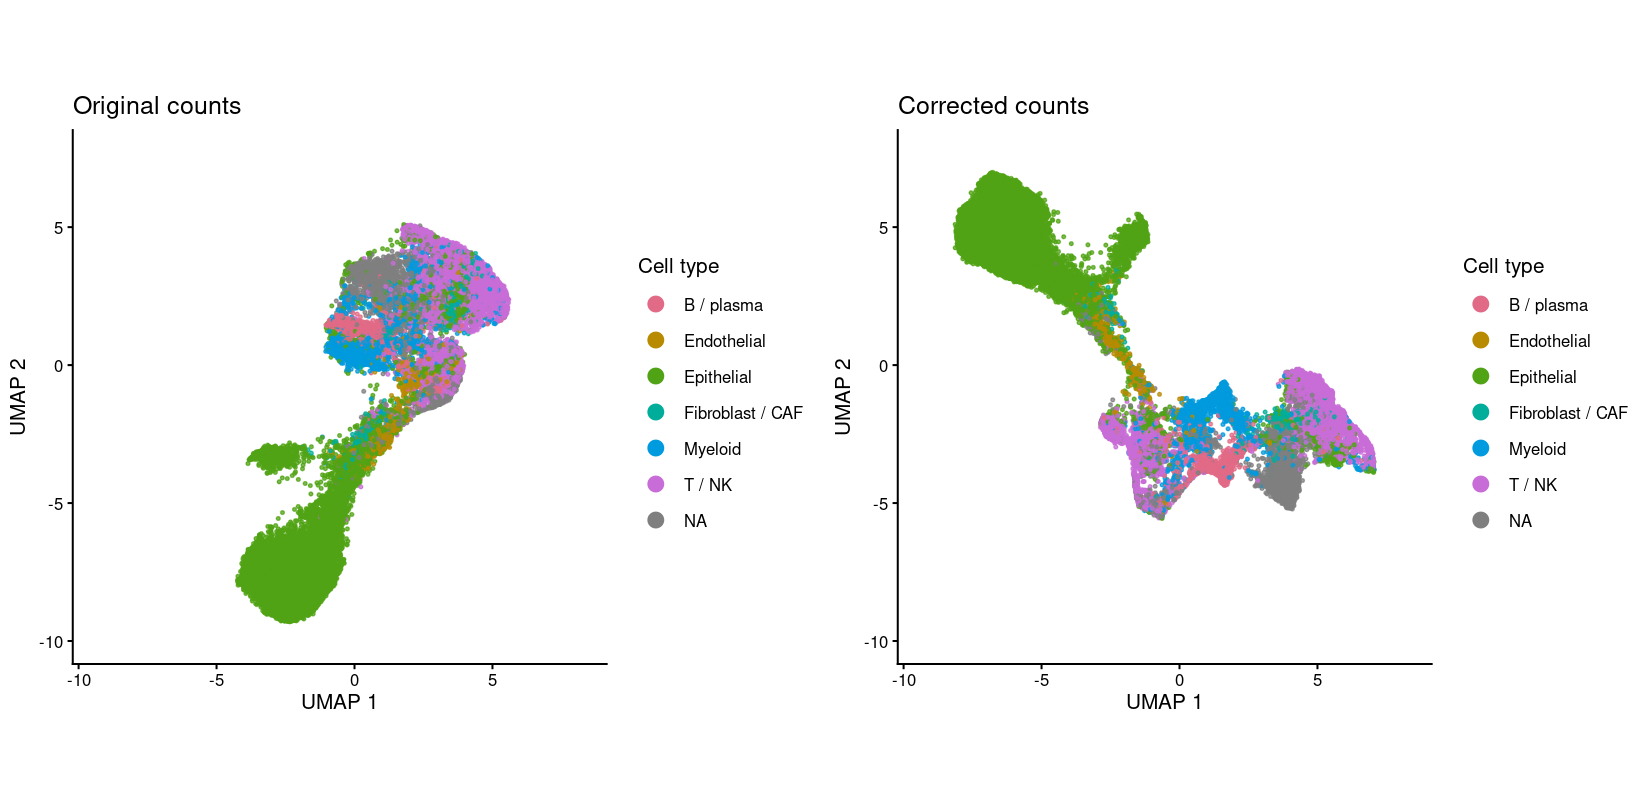

In [ ]:
state_umap_limits <- function(...) {
  frames <- list(...)
  x <- unlist(lapply(frames, `[[`, "umap_1"))
  y <- unlist(lapply(frames, `[[`, "umap_2"))
  span <- max(diff(range(x, na.rm = TRUE)), diff(range(y, na.rm = TRUE)))
  xmid <- mean(range(x, na.rm = TRUE))
  ymid <- mean(range(y, na.rm = TRUE))
  pad <- span * 0.04
  list(xlim = xmid + c(-1, 1) * (span / 2 + pad),
    ylim = ymid + c(-1, 1) * (span / 2 + pad))
}

plot_state_umap <- function(df, title, limits) {
  ggplot(df, aes(umap_1, umap_2, color = cell_type)) +
    geom_point(size = 0.55, alpha = 0.75) +
    coord_equal(xlim = limits$xlim, ylim = limits$ylim) +
    scale_color_manual(values = cell_type_palette, drop = FALSE) +
    labs(title = title, x = "UMAP 1", y = "UMAP 2", color = "Cell type") +
    theme_classic(base_size = 10) +
    guides(color = guide_legend(override.aes = list(size = 3.2, alpha = 1))) +
    theme(legend.position = "right")
}

limits <- state_umap_limits(original_state, corrected_state)
cowplot::plot_grid(plotlist = list(
  plot_state_umap(original_state, "Original counts", limits),
  plot_state_umap(corrected_state, "Corrected counts", limits)
), ncol = 2, align = "hv", axis = "tblr")